# Risk states and forced execution

I use fixed seeds here so the numerical examples remain comparable when the implementation changes.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd() if (Path.cwd()/"src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT/"src"))
pd.set_option("display.max_columns", 30)

I trace one stress path through reduce-only, cooldown, forced-reduction, and halted states to see exactly when the risk layer overrides the quote logic and what that intervention costs.

In [2]:
risk=pd.read_csv(ROOT/"outputs/data/representative_stress_full_risk_risk_events.csv")
risk

,step,time,state,reason_codes,inventory_before,inventory_after_risk_action,forced_trade_quantity,forced_execution_cost,liquidation_pnl,drawdown
0,123,0.492,halted,maximum_drawdown,4.0,0.0,4.0,0.2208,-10.811889,14.272284
1,124,0.496,halted,maximum_drawdown,0.0,0.0,0.0,0.0000,-10.811889,14.272284
2,125,0.500,halted,maximum_drawdown,0.0,0.0,0.0,0.0000,-10.811889,14.272284
3,126,0.504,halted,maximum_drawdown,0.0,0.0,0.0,0.0000,-10.811889,14.272284
4,127,0.508,halted,maximum_drawdown,0.0,0.0,0.0,0.0000,-10.811889,14.272284
...,...,...,...,...,...,...,...,...,...,...
122,245,0.980,halted,maximum_drawdown,0.0,0.0,0.0,0.0000,-10.811889,14.272284
123,246,0.984,halted,maximum_drawdown,0.0,0.0,0.0,0.0000,-10.811889,14.272284
124,247,0.988,halted,maximum_drawdown,0.0,0.0,0.0,0.0000,-10.811889,14.272284
125,248,0.992,halted,maximum_drawdown,0.0,0.0,0.0,0.0000,-10.811889,14.272284


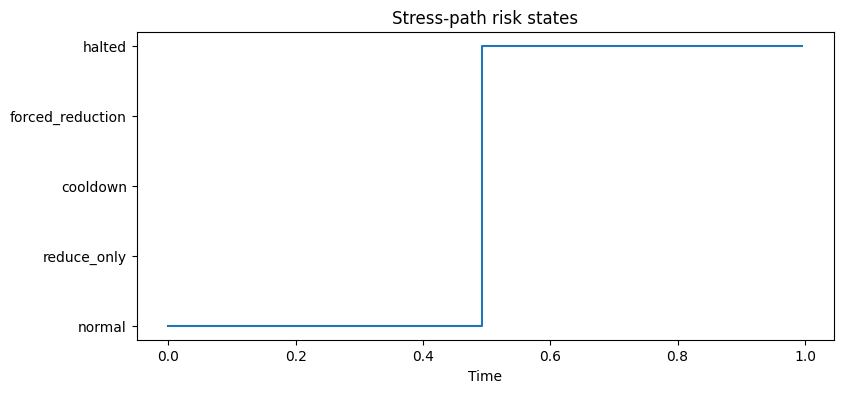

In [3]:
intervals=pd.read_csv(ROOT/"outputs/data/representative_stress_full_risk_intervals.csv")
mapping={"normal":0,"reduce_only":1,"cooldown":2,"forced_reduction":3,"halted":4}
plt.figure(figsize=(9,4)); plt.step(intervals.time_start,intervals.risk_state.map(mapping),where="post"); plt.yticks(list(mapping.values()),list(mapping.keys())); plt.xlabel("Time"); plt.title("Stress-path risk states"); plt.show()

In [4]:
pd.read_csv(ROOT/"outputs/tables/robustness_risk_limits.csv")

,hard_position_limit,mean_terminal_pnl,pnl_5_percentile,mean_maximum_inventory,mean_forced_reductions,mean_forced_execution_pnl,probability_of_loss
0,8.0,1.645931,-6.740967,7.200000,0.3,-0.096768,0.466667
1,14.0,1.561380,-12.865105,11.100000,0.0,0.000000,0.500000
2,24.0,0.965910,-23.638112,18.033333,0.0,0.000000,0.533333
